In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import pandas as pd
import numpy as np
import random
import pickle
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import PowerConsumptionDataset
from models.lstm import LSTMModel
from models.gru import GRUModel
from models.utils import create_model, train_and_evaluate, load_model
from explainers.lime import LimeExplainer
from explainers.shap import ShapExplainer

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
model_name = 'LSTM'  # or 'GRU', this can be changed based on the user's choice
hidden_size = 50
num_layers = 2
output_size = 1
dropout = 0.2
num_epochs = 50
batch_size = 64
learning_rate = 0.001
sequence_length = 60  # e.g., past 60 minutes
num_of_features = 4
input_size = num_of_features  # Number of total features in the dataset

model_path = './trained_models/{}_features_{}.pth'.format(model_name, num_of_features)
lime_path = './trained_explainer/lime_explainer_config.json'

In [4]:
dataset = PowerConsumptionDataset(file_path='data/household_power_consumption.txt',
                                  num_of_features=num_of_features)
train_sequences, eval_sequences, train_targets, eval_targets = dataset.load_data()

/archive/workspace/XAI/co-work/data/data_loader.py:18: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv(self.file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/archive/workspace/XAI/co-work/data/data_loader.py:18: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv(self.file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/archive/workspace/XAI/co-work/data/data_loader.py:18: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv(self.file_path, sep=';', parse_dates

In [5]:
model = create_model(model_name, input_size, hidden_size, num_layers, output_size, dropout)

# Check if the model already exists
if os.path.exists(model_path):
    print(f"Loading the pre-trained {model_name} model...")
    model = load_model(model, model_path)
    model.to(device)
else:
    print(f"Training a new {model_name} model...")
    train_and_evaluate(model, train_sequences, train_targets, 
                       eval_sequences, eval_targets, model_path,
                       num_epochs, batch_size, learning_rate)

Loading the pre-trained LSTM model...


## Explain

### LIME

In [7]:
explainer_type = 'LIME'  # or 'SHAP'

if explainer_type == 'LIME':
    explainer = LimeExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
elif explainer_type == 'SHAP':
    explainer = ShapExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
else:
    raise ValueError(f"Explainer type '{explainer_type}' is not recognized.")

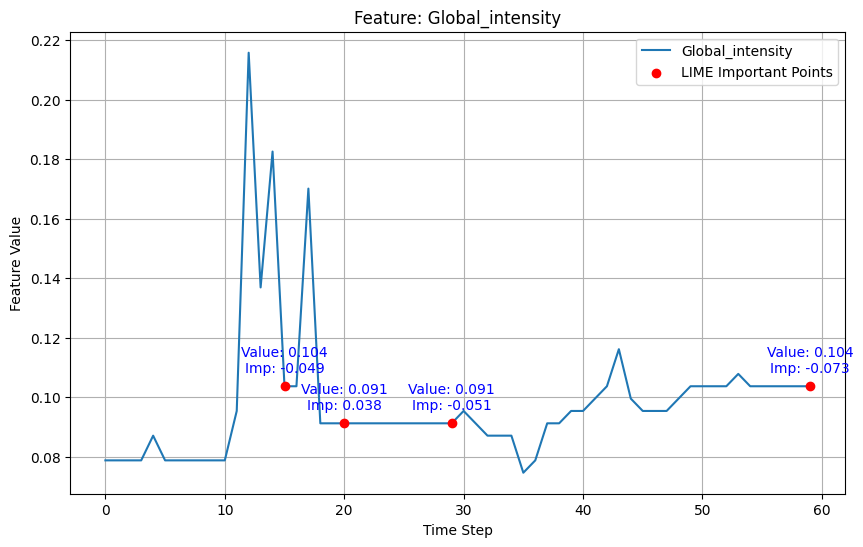


Feature: Global_intensity - Detailed Information
Time Step: 59, Feature Value: 0.104, Importance: -0.073
Time Step: 29, Feature Value: 0.091, Importance: -0.051
Time Step: 15, Feature Value: 0.104, Importance: -0.049
Time Step: 20, Feature Value: 0.091, Importance: 0.038


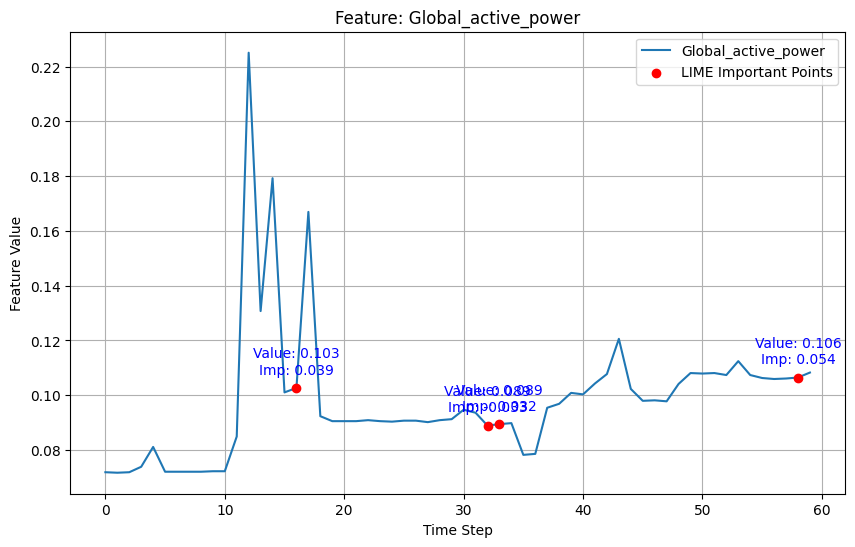


Feature: Global_active_power - Detailed Information
Time Step: 58, Feature Value: 0.106, Importance: 0.054
Time Step: 16, Feature Value: 0.103, Importance: 0.039
Time Step: 32, Feature Value: 0.089, Importance: -0.033
Time Step: 33, Feature Value: 0.089, Importance: 0.032


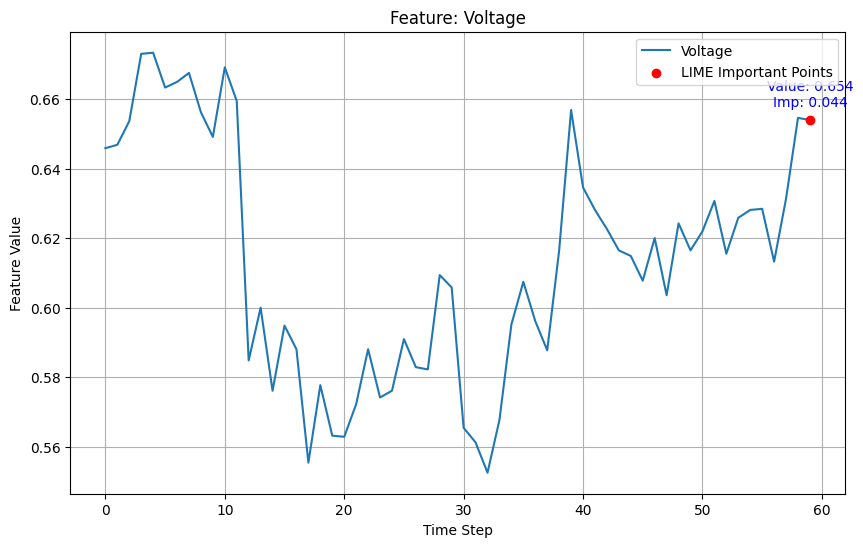


Feature: Voltage - Detailed Information
Time Step: 59, Feature Value: 0.654, Importance: 0.044


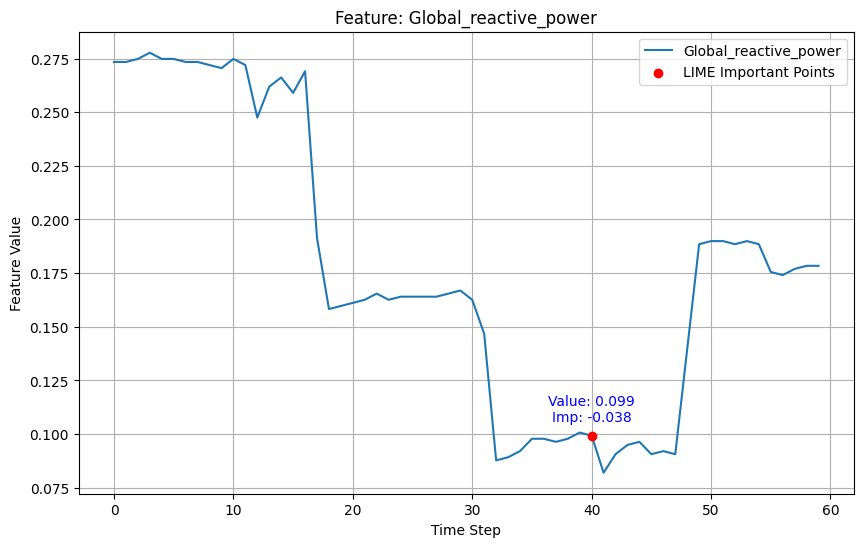


Feature: Global_reactive_power - Detailed Information
Time Step: 40, Feature Value: 0.099, Importance: -0.038


In [8]:
# Explain a specific data point
explanation = explainer.explain(train_sequences[0])

### SHAP

In [9]:
explainer_type = 'SHAP' 

if explainer_type == 'LIME':
    explainer = LimeExplainer(model, device, train_sequences, 
                              sequence_length=60, input_size=input_size, 
                              selected_features=dataset.selected_features)
elif explainer_type == 'SHAP':
    explainer = ShapExplainer(model, train_sequences, sequence_length, 
                              input_size, dataset.selected_features, device)

else:
    raise ValueError(f"Explainer type '{explainer_type}' is not recognized.")

  0%|          | 0/1 [00:00<?, ?it/s]

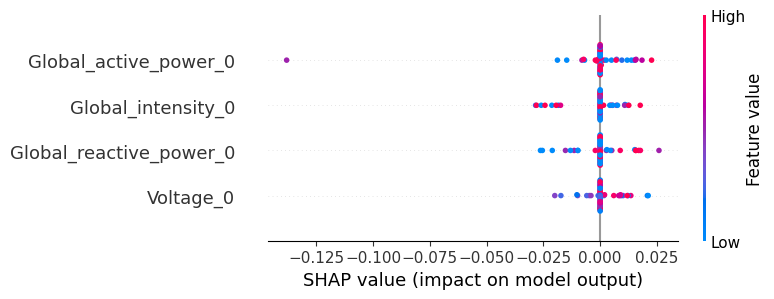

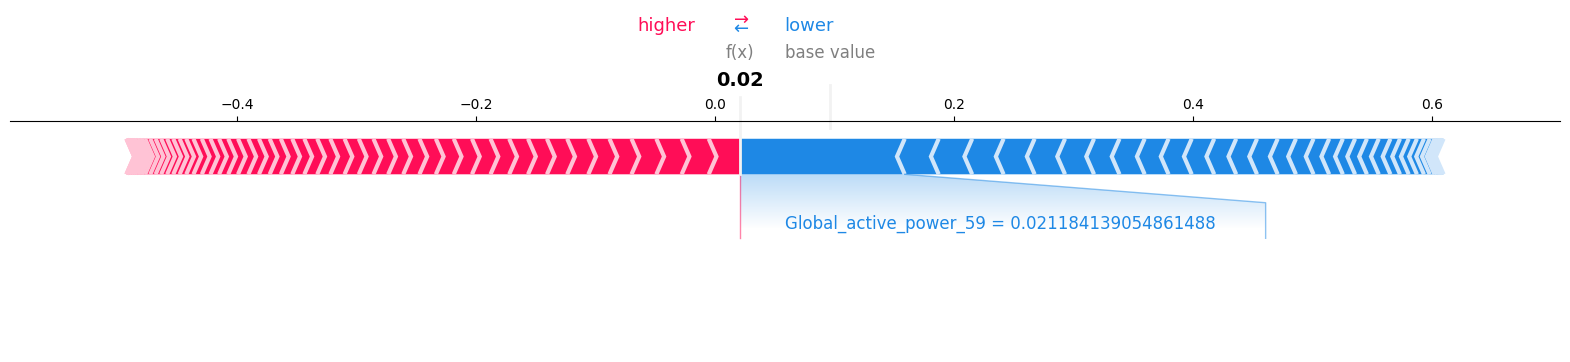

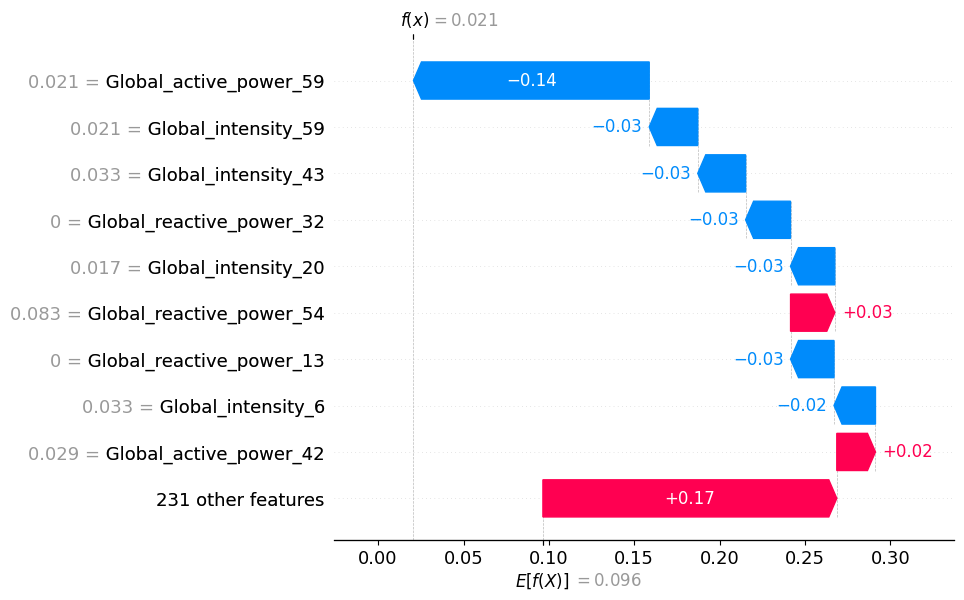

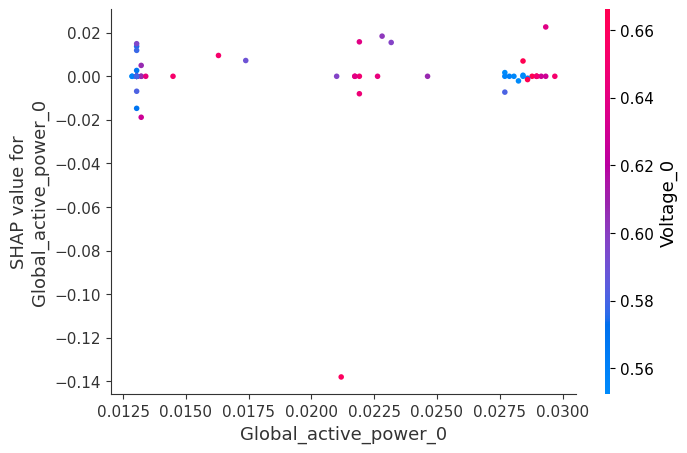

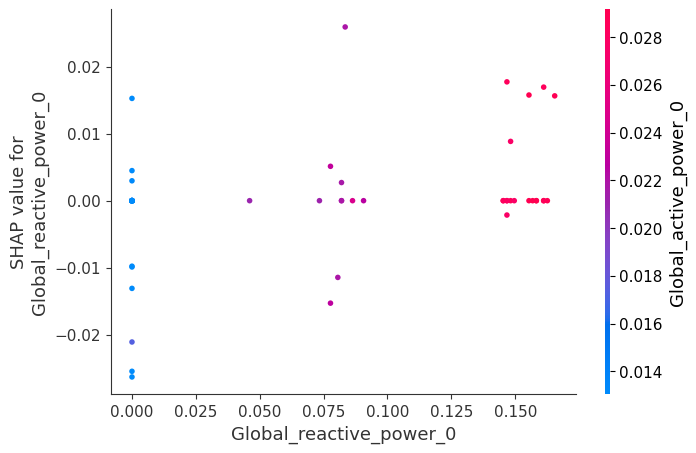

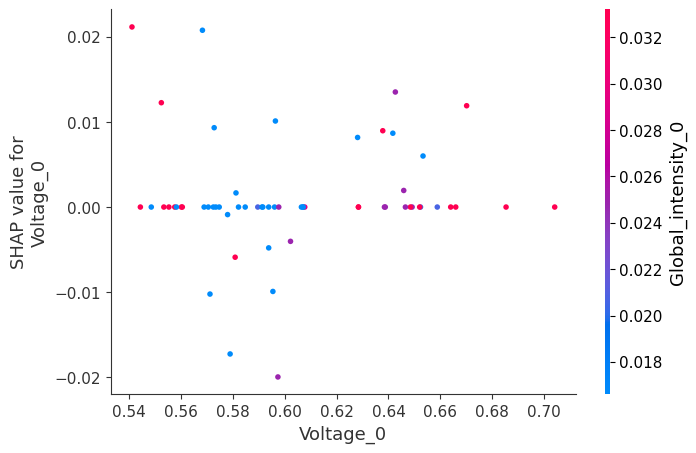

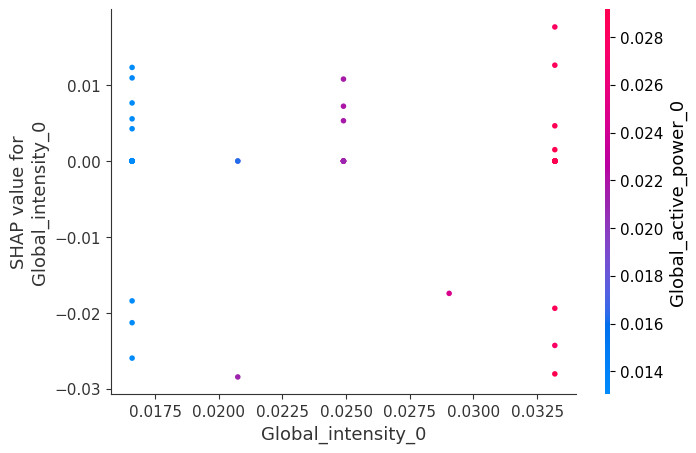

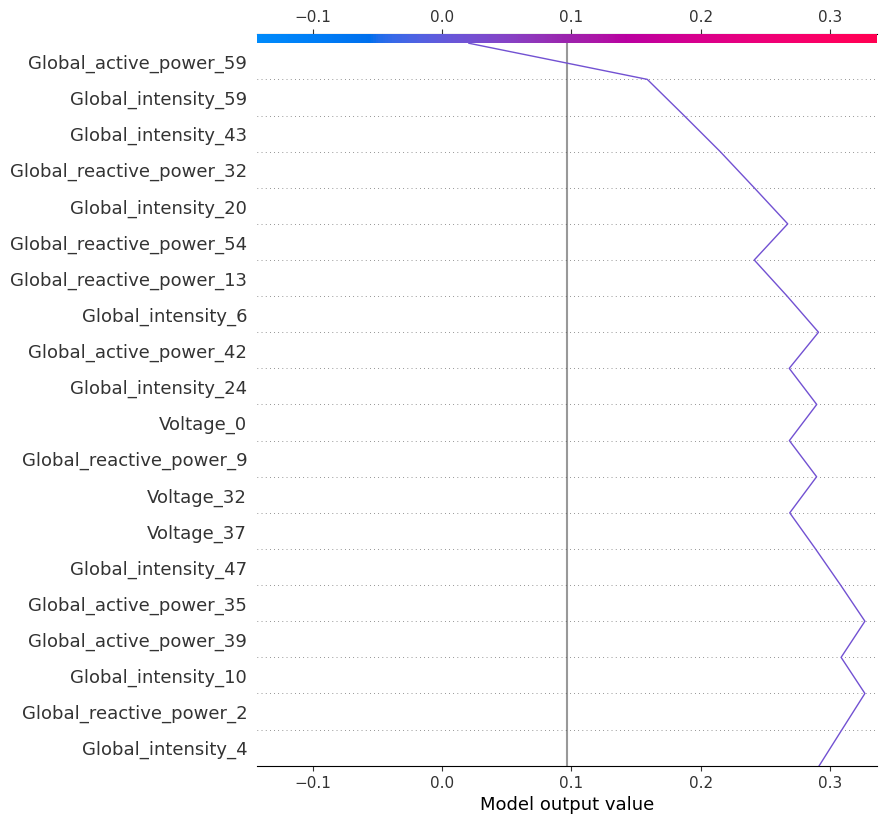

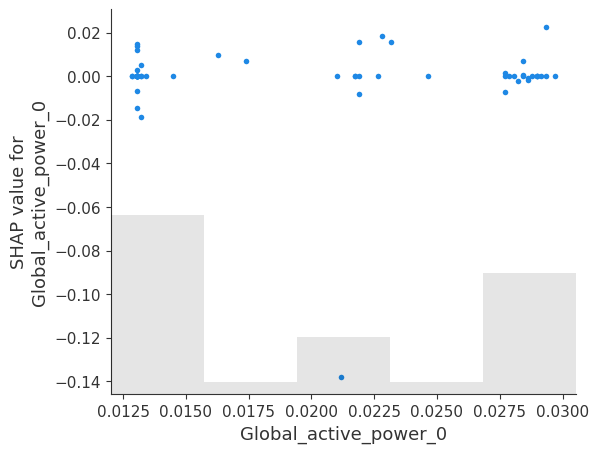

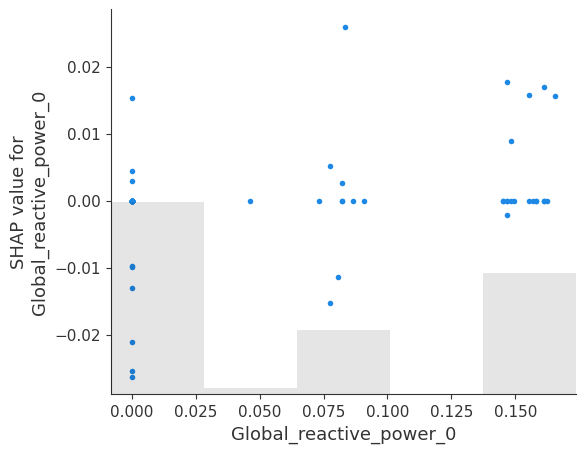

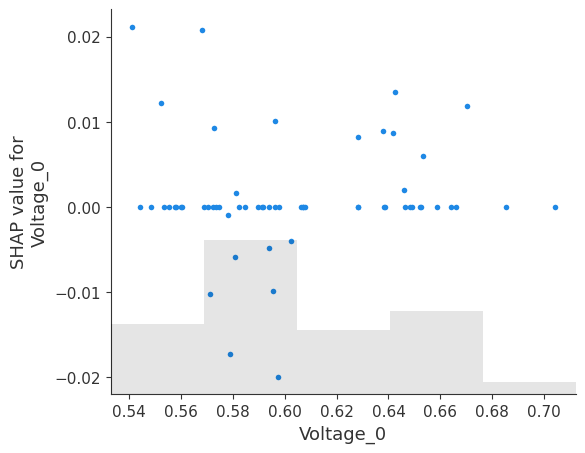

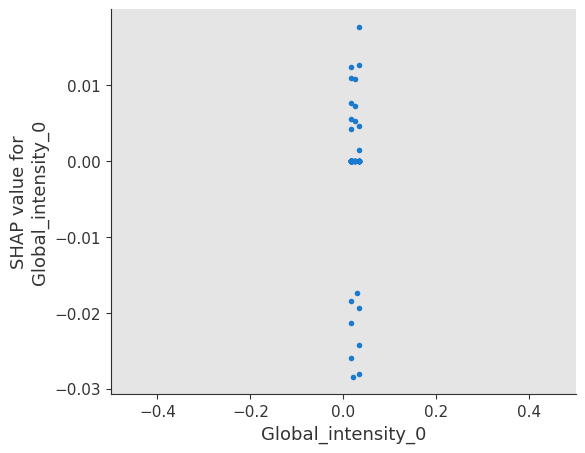

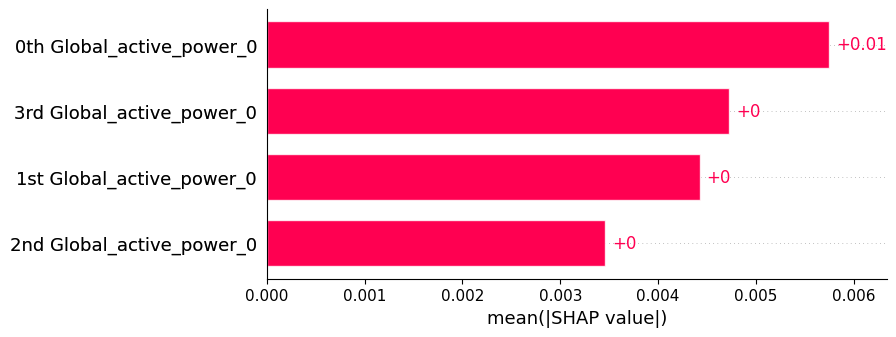

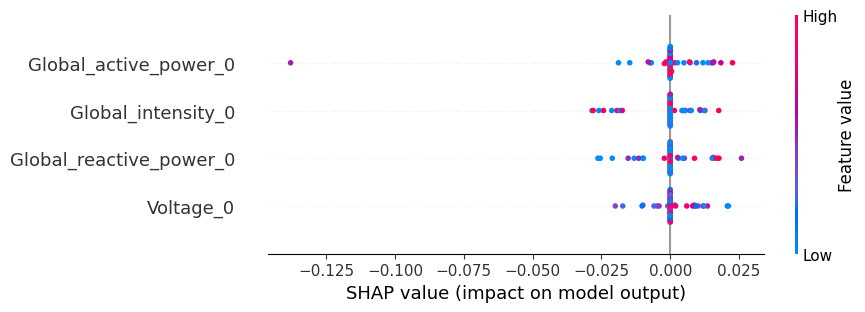

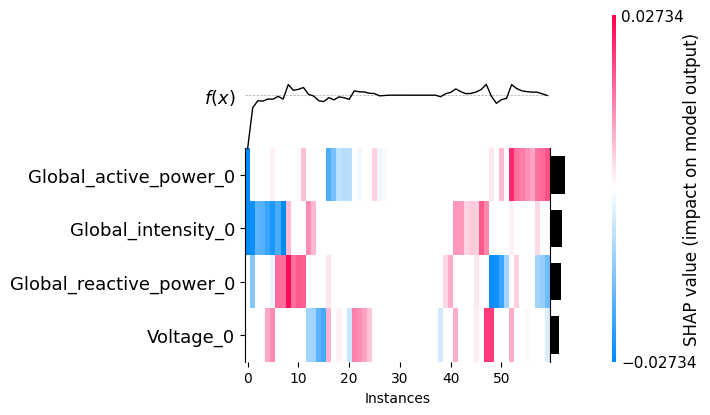

Feature Global_active_power not found in sample_df columns: Index(['Global_active_power_0', 'Global_reactive_power_0', 'Voltage_0',
       'Global_intensity_0'],
      dtype='object')


In [10]:
num_samples = 1  
shap_values, sampled_eval_sequences = explainer.explain(eval_sequences,
                                                             num_samples=num_samples)

explainer.visualize(shap_values, sampled_eval_sequences)